# SR Tutorial

2026 IAIFI Summer School

Tutorial lead: Jose M Munoz Arias

Professor: Miles Cranmer

# From wavefunction to potential

Every problem so far has run the same way round, the last one included. Somebody hands you a
system, you write down what governs it, and you look for the thing it does. We were given $V$ and
we went looking for $\psi$. This one runs backwards.

Suppose there is a cloud of atoms in an optical trap and you take a picture of it.
What the camera gives you is how many atoms sit at each position, which is $|\psi|^2$, and that is
genuinely all it gives you. It does not give you the trap. Nobody can photograph a potential.

So, from the picture alone, what is the potential?

It has the same shape as the inverse Kohn-Sham problem in electronic
structure, and the same shape as calibrating an optical trap you built yourself and only partly
trust.

But not only that, it also extends to things like nuclear physics, where we actually don't know the shape of the inter-nucleon potential.

---

In [1]:
# Uncomment on Colab.
# import subprocess, sys
# subprocess.run([sys.executable, "-m", "pip", "install", "-q", "pysr", "sympy>=1.14"], check=True)

In [2]:
import os
os.environ.setdefault("PYTHON_JULIACALL_THREADS", "auto")
os.environ.setdefault("PYTHON_JULIACALL_AUTOLOAD_IPYTHON_EXTENSION", "no")

import time

import numpy as np
import sympy

t0 = time.time()
import pysr
from pysr import PySRRegressor
print(f"pysr {pysr.__version__} imported in {time.time() - t0:.0f}s")

import session4_data as s4
from session4_data import (image_density, local_curvature, potential_for,
                           read_equation, true_potential, X_SYM)

REPRO = dict(deterministic=True, parallelism="serial", verbosity=0, progress=False)

pysr 1.5.9 imported in 23s


## 1. The picture

This is the data, and there is no more where it came from. A density profile, in arbitrary units,
of a cloud sitting in a trap nobody has told us about.

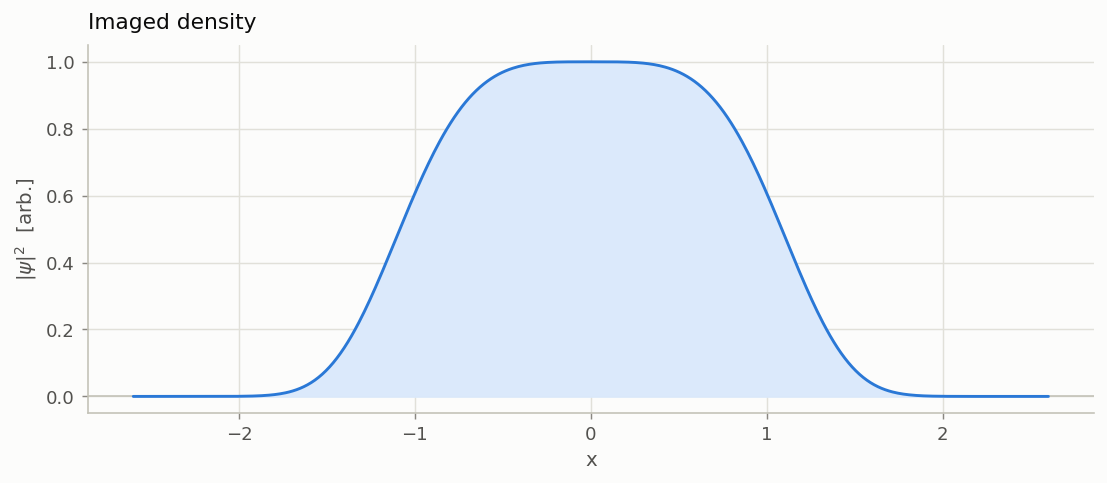

In [3]:
x, density = image_density(noise_pct=0.0)
s4.plot_image(x, density)

One lump, with a flat top. The flat top is the only thing the eye gets to work with, and it is a
weak hint, since a trap with a single minimum would have given us something rounder. Whether
there are one or two minima underneath is not a question staring at this will settle, and the
picture says nothing at all about how steep the walls are out where there are no atoms to be
steep against.

## 2. One rearrangement

The time-independent Schrödinger equation, in units where $\hbar = m = 1$, is

$$-\tfrac12 \psi'' + V\psi = E\psi.$$

Solve it for $V$ rather than for $\psi$ and there is nothing left to do:

$$V(x) - E = \frac{\psi''(x)}{2\,\psi(x)}.$$

Everything on the right comes from the picture, since the density is $|\psi|^2$ and a ground state
can be taken real and positive, so $\psi$ is its square root.

Notice what is missing. Nothing here separates $V$ from $E$, and nothing ever will, because adding
a constant to a potential shifts every level by that constant and leaves every density exactly as
it was. The zero of energy is not in the data. We can recover the shape of the trap and not its
offset, which is a statement about physics rather than about our method.

## 3. The obvious thing, and what it does to us

So compute the right-hand side and look at it. The density gives $\psi$, a Savitzky-Golay filter
gives $\psi''$, which is the same move as the robot notebook, and then we divide.

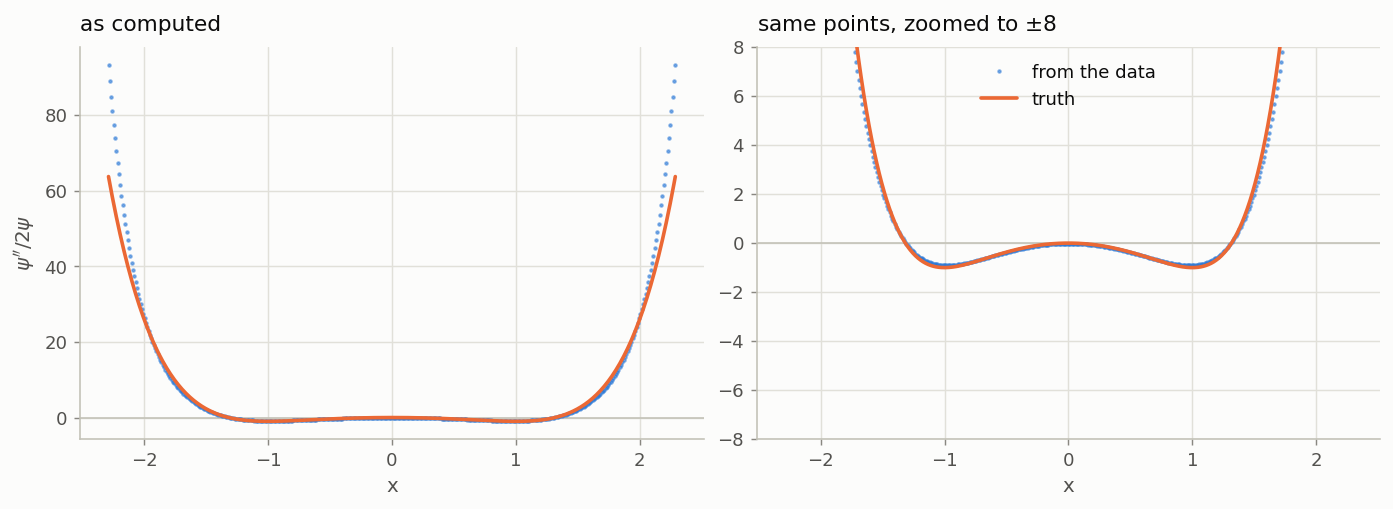

In [4]:
xs, target, weight = local_curvature(x, density)
s4.plot_raw_target(xs, target, weight, truth=true_potential)

The right panel is the same numbers as the left with the axis cut down to a range a person would
care about, and the double well is sitting there plainly enough. So far this looks like it worked.

It did not, quite, and the reason is worth measuring rather than eyeballing. We divided by $\psi$,
and $\psi$ falls to nothing in the wings, so the formula amplifies hardest exactly where the
measurement is weakest. The last handful of points reach ninety-odd while the feature we actually
came for, the well, is one unit deep.

In [5]:
Vt = true_potential(xs)
plain = np.sqrt(np.mean((target - Vt) ** 2))
wtd = np.sqrt(np.sum(weight * (target - Vt) ** 2) / np.sum(weight))
print(f"treating every point equally     rms error {plain:8.3f}")
print(f"weighting each point by density  rms error {wtd:8.3f}")
print(f"                for scale, the well is about {abs(Vt.min()):.1f} deep")

treating every point equally     rms error    4.837
weighting each point by density  rms error    0.075
                for scale, the well is about 1.0 deep


A plain fit would be chasing an error five times larger than the thing it is meant to find, and
all of that error lives in a few points out where there are no atoms.

## 4. Trust it where the atoms are

The repair is the one from this morning's drag problem, which is to state what we believe about
the data as a weight rather than to argue with the formula.

Every point gets a weight of $\psi^2$, which is the density, which is how many atoms were counted
there. Doing that is the same as fitting the equation in the form

$$\psi'' = 2\,(V - E)\,\psi,$$

which is where it should have been all along, since multiplying through by $\psi$ removes the
division that caused the trouble. `local_curvature` already returned those weights.

In [6]:
SEARCH = dict(binary_operators=["+", "-", "*"], niterations=40, maxsize=20,
              random_state=0, **REPRO)

def find_potential(xs, target, weight):
    t = time.time()
    m = PySRRegressor(**SEARCH)
    m.fit(xs.reshape(-1, 1), target, weights=weight, variable_names=["x"])
    print(f"{time.time() - t:.0f}s")
    return m

clean = find_potential(xs, target, weight)
clean.equations_[["complexity", "loss", "score", "equation"]].tail(6)

57s


,complexity,loss,score,equation
2,9,0.092455,7.725065e-01,x * (((x * x) - 1.6678907) * x)
3,11,0.036423,4.657578e-01,((x * -1.5025642) * x) * (1.5896556 - (x * x))
4,13,0.032069,6.365545e-02,(((x * 1.591093) * ((x * x) - 1.6446345)) * x)...
5,15,0.032069,6.236498e-08,(((x * x) * 1.591085) * (((x * x) + -0.0583468...
6,17,0.003843,1.060788e+00,x * (((((x * x) * (x * (x * x))) - x) * 0.4776...
7,19,0.002060,3.118514e-01,((((x * x) * (((x * x) * x) * 0.6654576)) - x)...


x * (((((x * x) * (x * (x * x))) - x) * 0.47765437) - x)
expanded: 0.47765437*x**6 - 1.47765437*x**2


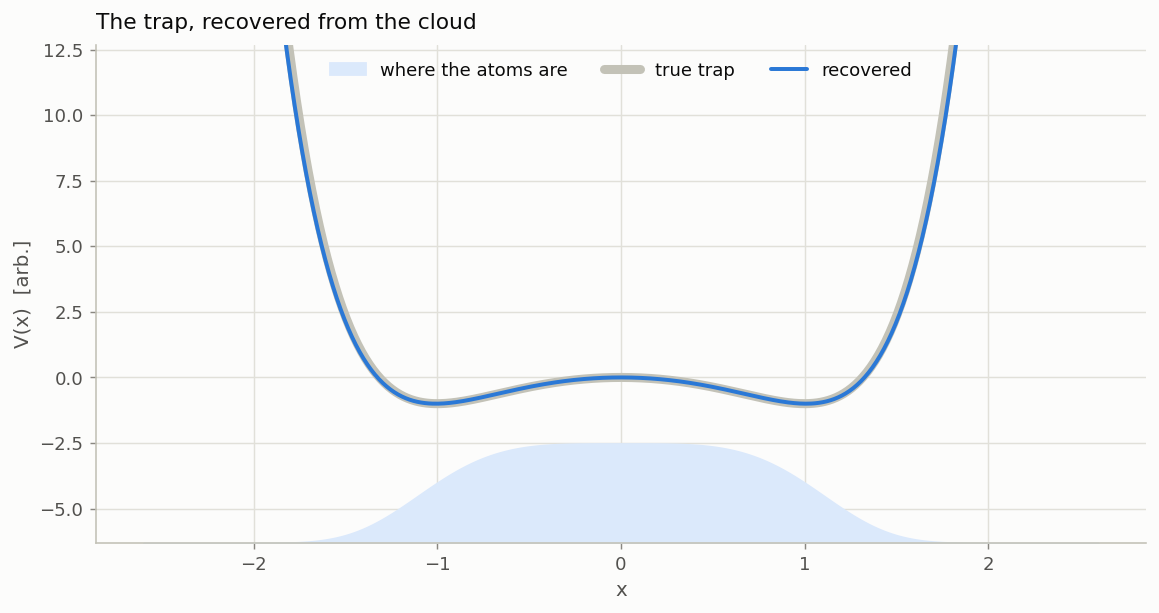

In [7]:
row = clean.equations_.iloc[clean.equations_["score"].argmax()]
print(row.equation)
print("expanded:", sympy.expand(sympy.sympify(row.equation)))
s4.plot_recovered(x, read_equation(row.equation), truth=true_potential, density=density)

A double well, with minima near $x = \pm 1$ and a barrier between them, recovered from a picture of
where some atoms were sitting.

The state living in it is $\psi = e^{-x^4/4}$, which is worth a moment on its own. Quartic double
wells, the ones everybody draws when they talk about tunnelling and qubits, have no closed-form
ground state at all. This sextic one does, and that is why it is the example.

## 5. Now take a real picture

That was a perfect image. Real cameras have noise, so put some in. Not much: one part in ten
thousand of the peak density, which is a better image than most laboratories manage on a good day.

In [8]:
x_n, density_n = image_density(noise_pct=0.01)
xs_n, target_n, weight_n = local_curvature(x_n, density_n)

noisy = find_potential(xs_n, target_n, weight_n)
row_n = noisy.equations_.iloc[noisy.equations_["score"].argmax()]
print(row_n.equation)
print("expanded:", sympy.expand(sympy.sympify(row_n.equation)))

17s
((x * x) - 1.6701003) * (x * x)
expanded: x**4 - 1.6701003*x**2


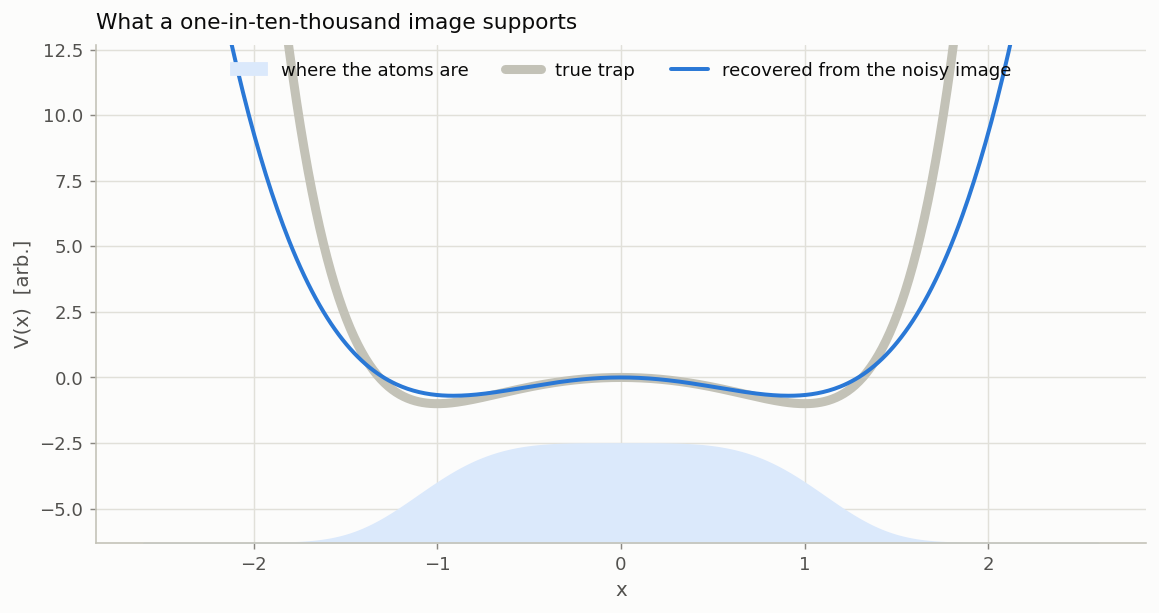

In [9]:
s4.plot_recovered(x_n, read_equation(row_n.equation), truth=true_potential,
                  density=density_n, label="recovered from the noisy image",
                  title="What a one-in-ten-thousand image supports")

The $x^6$ has gone, and what comes back is a quartic. It is worth putting numbers on what that
costs us, because the picture on its own will flatter it.

Where the atoms are, the quartic follows the true sextic closely. It puts the minima at
$x = \pm 0.91$ against a true $\pm 1$, so the shape of the trap survives, and it makes the well
$0.70$ deep against a true $1.0$, so the depth comes back about thirty percent shallow. Follow the
two curves outwards and they part company in earnest near $|x| = 1.5$, by which point the density
is down to eight percent of its peak and fewer than one atom in a hundred has ever been there.

That last number is the whole argument. The $x^6$ term only shifts the potential by as much as the
well is deep once we are past $|x| = 1.5$, and $|x| = 1.5$ is already the edge of the cloud. Inside
it the term hides under the noise, and no amount of searching will pull it back out, because the
information was never recorded in the first place. An atom that never visits a region cannot report
on the potential there.

That is the character of inverse problems, and it is a different failure from the ones we have
seen today. Nothing overfitted, no prior was missing, and the search behaved impeccably. The data
does not contain the answer past a certain radius, and the useful skill is knowing where that
radius falls.

## 6. The other direction, which is more fun

Nothing forces us to start from a measurement. The identity reads just as well forwards: name any
smooth, nodeless, normalisable $\psi$ you like and it hands back the universe in which that state
is the ground state.

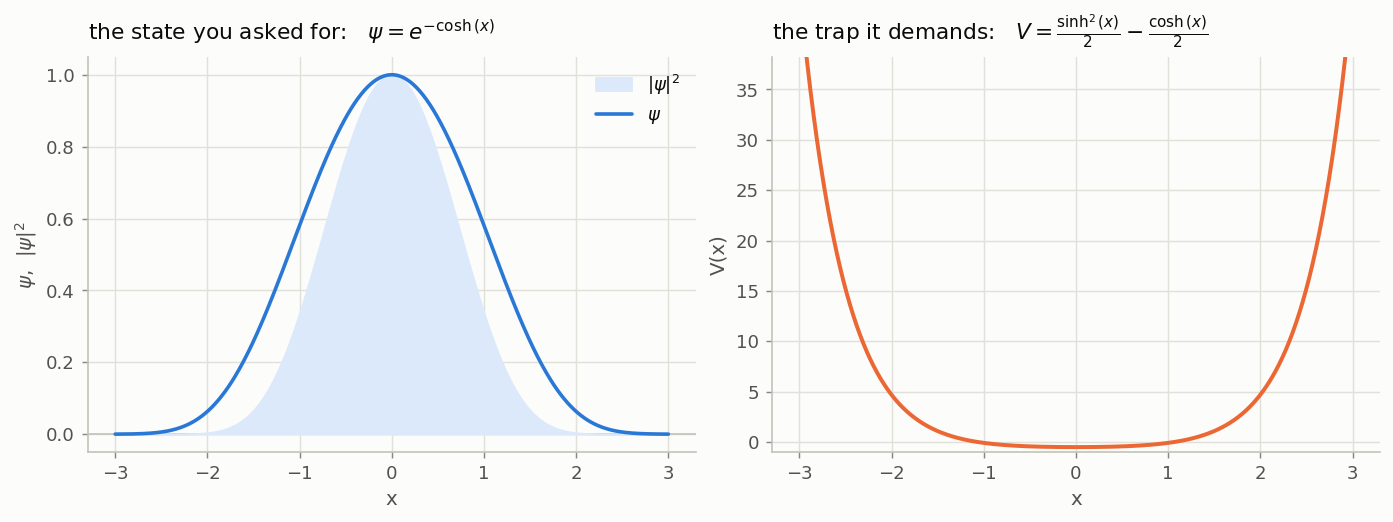

psi = exp(-cosh x)   ->   V = sinh(x)**2/2 - cosh(x)/2


In [10]:
x_ = X_SYM
V = s4.plot_design(sympy.exp(-sympy.cosh(x_)))
print("psi = exp(-cosh x)   ->   V =", V)

That potential has no name and appears in no textbook. It exists because we asked for a state
shaped like that.

**Try this.** Change the expression above and rerun the cell. Some suggestions, all of which come
out in closed form: `sympy.exp(-x_**6/6)`, `sympy.exp(-x_**2/2 - x_**4/4)`, `1/sympy.cosh(x_)`,
`sympy.exp(-sympy.sqrt(1 + x_**2))`. Keep it nodeless and make sure it decays, or what comes back
will not be a bound state of anything.